In [1]:
%load_ext autoreload
%autoreload 2

from copy import copy
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib

from koala.voronization import generate_lattice
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala import plotting as pl
from alter_morph.lattice_utilities import add_contacts
from alter_morph.kwant_version import (
    kwant_altermagnetic_hamiltonian,
    cumulative_density,
)
from kwant import kpm
from kwant.kpm import fermi_distribution

from koala.lattice import Lattice
from koala.graph_color import color_lattice
from tqdm import tqdm

from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_m_values,
    find_spin_per_state,
    fermi_probability,
    spectral_function,
)

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)

import kwant
from alter_morph.kwant_version import Amorphous

from time import time

aps_figwidth = 6.6
aps_halfwidth = 3.375

/opt/homebrew/Caskroom/miniforge/base/envs/kwant-test/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "


Lattice(900 vertices, 1800 edges) Lattice(900 vertices, 1350 edges) Lattice(900 vertices, 1800 edges)


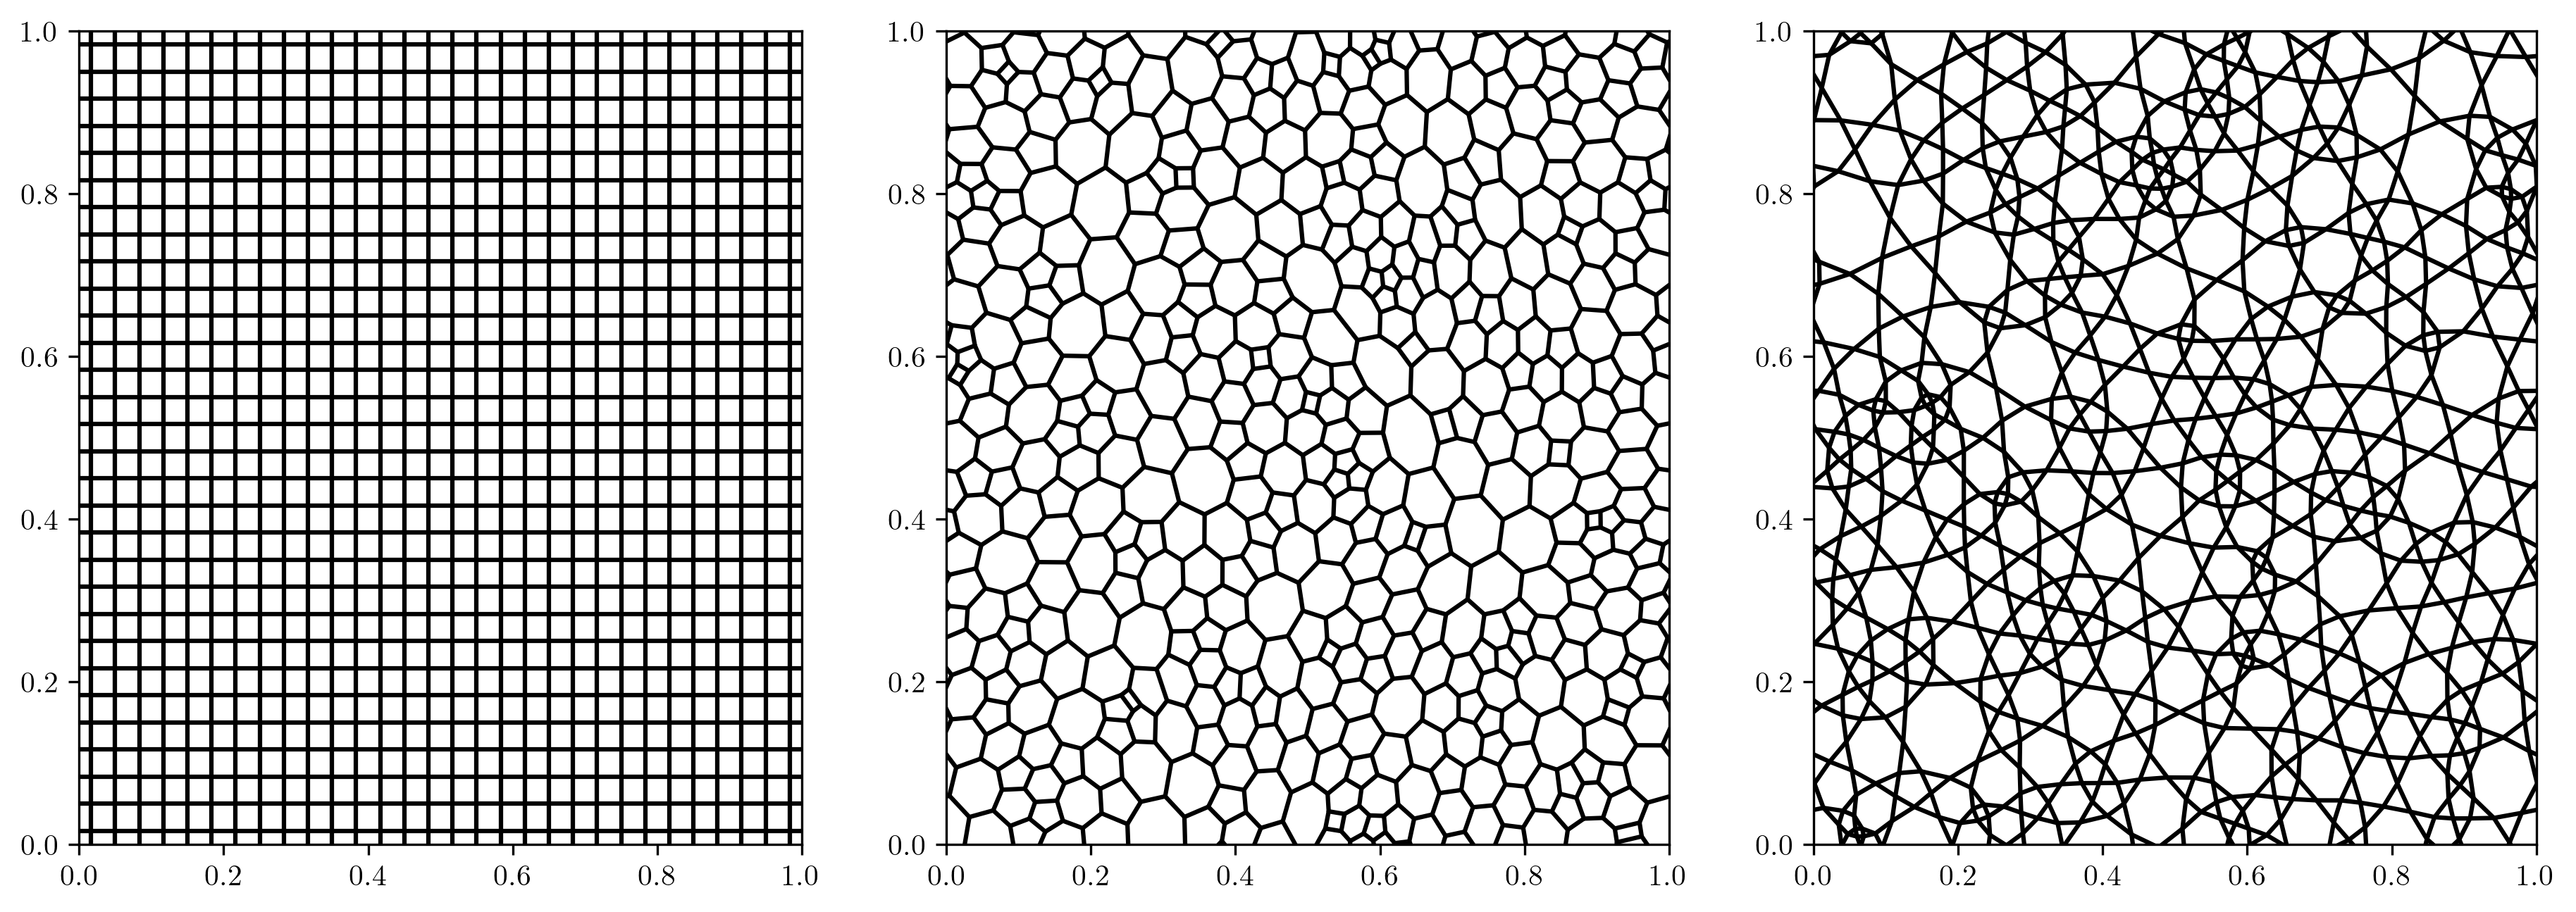

In [2]:
# generate the lattice
n_vertices = 30**2
points = uniform(n_vertices)

vor_lat = generate_lattice(uniform(n_vertices // 2))
dimerisation = gu.dimerise(vor_lat)
lattice1 = gu.lloyd_relaxation(vor_lat, 10)
# lattice1 = add_contacts(lattice1, cross_edges=True)

l2 = generate_lattice(uniform(n_vertices // 3))
l2 = gu.lloyd_relaxation(l2, 10)
exp_lat = gu.vertices_to_polygon(l2)
dimer_exp = np.zeros(exp_lat.n_edges)
dimer_exp[: l2.n_edges] = 1
lattice2 = gu.dimer_collapse(exp_lat, dimer_exp)
# lattice2 = add_contacts(lattice2, cross_edges=True)

rows = np.round(np.sqrt(n_vertices)).astype(int)
lattice0 = eg.square_lattice(rows, rows)
# lattice0 = add_contacts(lattice0, cross_edges=True)

fig, ax = plt.subplots(1, 3, figsize=(15, 5), dpi=300)
pl.plot_edges(lattice0, ax=ax[0])
pl.plot_edges(lattice1, ax=ax[1])
pl.plot_edges(lattice2, ax=ax[2])

print(lattice0, lattice1, lattice2)

In [3]:
# set the parameters
t1 = 1
t2 = 0.3
J = 0.4
filling = 0.5
lat = lattice1
m_guess = 1.2


# generate the kwant system
initial_m = m_guess * np.ones(lat.n_vertices)
k_system = kwant_altermagnetic_hamiltonian(lat, t1, t2, J, initial_m).finalized()

# check hermitian
ham = k_system.hamiltonian_submatrix()
assert np.allclose(ham, ham.T.conj())


In [4]:
# set kpm parameters
num_moments = 50
num_vectors = 2000
sum_flag = False
params = dict(num_vectors=num_vectors, num_moments=num_moments)

# operators for local dos and magnetisation
number_density = kwant.operator.Density(
    k_system, sum=sum_flag, onsite=np.diag([1, 1, 1, 1]), check_hermiticity=True
)

magnetisation = kwant.operator.Density(
    k_system, sum=sum_flag, onsite=np.diag([1, -1, -1, 1]), check_hermiticity=True
)


# calculate the dos and magnetisation
local_dos = kwant.kpm.SpectralDensity(k_system, operator=number_density, **params)
local_mag = kwant.kpm.SpectralDensity(k_system, operator=magnetisation, **params)
global_dos = kwant.kpm.SpectralDensity(k_system, **params)


# find the fermi level and the distribution for the filling
fermi_level = np.interp(filling, *cumulative_density(global_dos)[::-1])


# spatially resolved dos and magnetisation at filling
fd = lambda E: fermi_distribution(E, fermi_level, 0)
local_occupation = local_dos.integrate(fd).real
local_magnetisation = local_mag.integrate(fd).real


In [ ]:
# now let's do the mean field iteration
n_iterations = 20
m_values = np.zeros((n_iterations + 1, lat.n_vertices))
m_values[0] = local_magnetisation

prange = tqdm(range(n_iterations))
counter = 0
for n in prange:
    k_system = kwant_altermagnetic_hamiltonian(lat, t1, t2, J, initial_m).finalized()
    magnetisation = kwant.operator.Density(
        k_system, sum=sum_flag, onsite=np.diag([1, -1, -1, 1])
    )
    local_mag = kwant.kpm.SpectralDensity(k_system, operator=magnetisation, **params)
    fermi_level = np.interp(filling, *cumulative_density(global_dos)[::-1])
    m_values[n + 1] = local_mag.integrate(
        lambda E: fermi_distribution(E, fermi_level, 0)
    ).real

    diff = np.linalg.norm(m_values[n + 1] - m_values[n])
    avg_m = np.mean(m_values[n + 1])
    prange.set_description(f"Avg:{avg_m:.2f}, diff: {diff:.6f}")

    if diff < 1e-6:
        counter += 1
        if counter > 2:
            m_values = m_values[: n + 1]
            break


  0%|          | 0/20 [00:00<?, ?it/s]

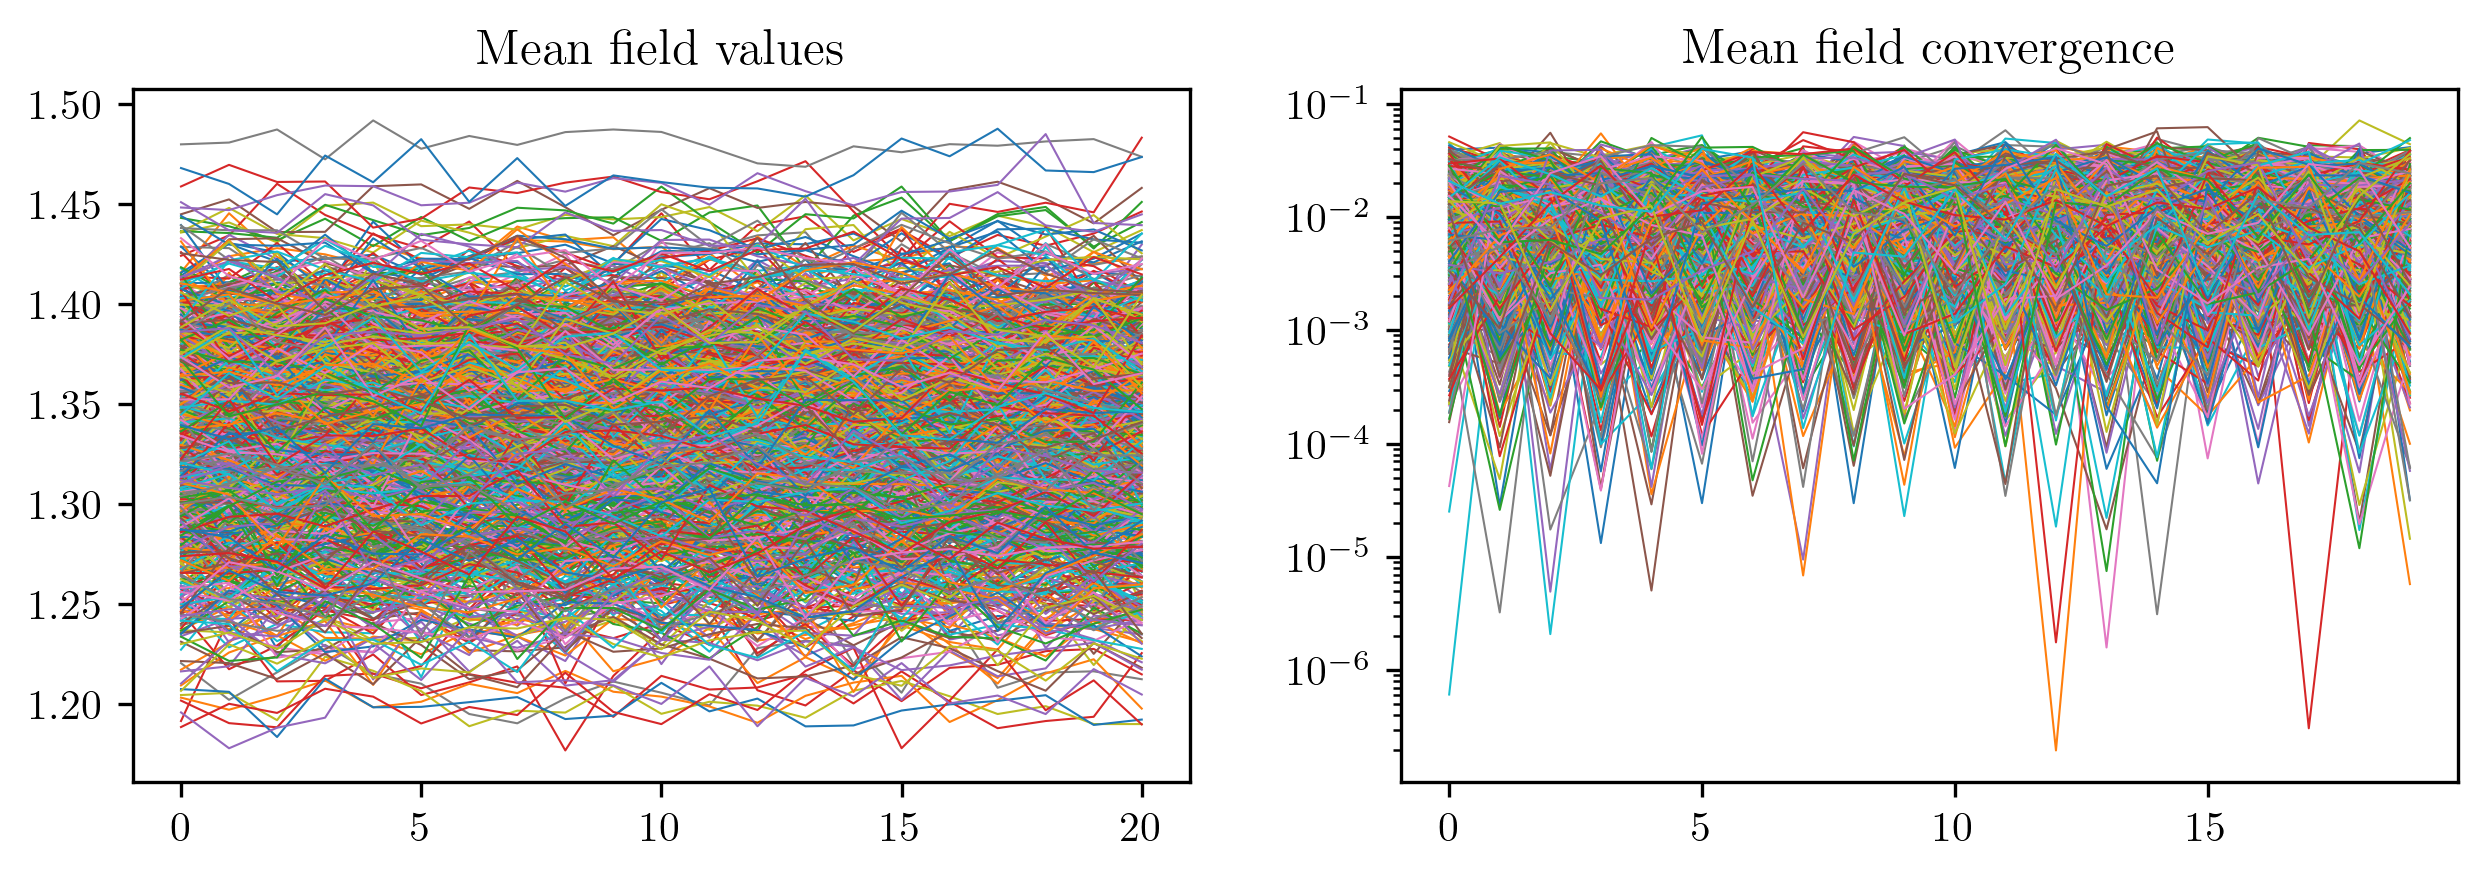

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3), dpi=300)
ax[0].plot(m_values, linewidth=0.5)

diffs = np.diff(m_values, axis=0)
ax[1].plot(np.abs(diffs), linewidth=0.5)


ax[0].set_title("Mean field values")
ax[1].set_title("Mean field convergence")
ax[1].set_yscale("log")
plt.show()

Text(0, 0.5, 'Imaginary part')

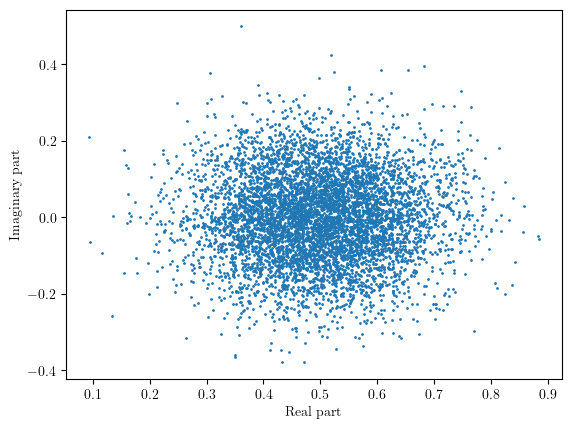

In [ ]:
# necessary imports
import kwant
import numpy as np


# define the system
def make_syst(r=30, t=-1, a=1):
    syst = kwant.Builder()
    lat = kwant.lattice.honeycomb(a, norbs=1)

    def circle(pos):
        x, y = pos
        return x**2 + y**2 < r**2

    syst[lat.shape(circle, (0, 0))] = 0.0
    syst[lat.neighbors()] = t
    syst.eradicate_dangling()

    return syst


fsyst = make_syst().finalized()

kwant_op = kwant.operator.Density(fsyst, sum=False, check_hermiticity=True)
local_dos = kwant.kpm.SpectralDensity(fsyst, operator=kwant_op)
densities = local_dos.integrate(lambda E: fermi_distribution(E, 0, 0))
plt.scatter(densities.real, densities.imag, s=1)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")